# 01 | Input Embeddings & Positional Encoding
## Sprint 1 — Day 1

**Previous notebook:** `00_introduction.ipynb` — project overview and motivation.

---

In this notebook we solve the first problem every Transformer faces:
*how do we turn a sequence of tokens into a form the model can reason about,
while preserving the order of those tokens?*

We will build two components:

1. **Token Embeddings** — a learned lookup table that maps each token index
   to a dense vector of dimension `d_model`.
2. **Positional Encoding (PE)** — a fixed sinusoidal matrix that encodes each
   token's position in the sequence as a unique numerical fingerprint,
   added on top of the token embedding.

These two components together produce the input tensor that flows into every
subsequent layer of the Transformer.

---

**By the end of this notebook you will have:**
- Implemented sinusoidal positional encoding from the original formula
- Visualised the encoding matrix as a heatmap and understood what you see
- Built an `InputEmbedding` PyTorch module that combines both components
- Produced a tensor of shape `(batch_size, seq_len, d_model)` — the universal
  input format for everything that follows

---

*Next notebook: `02_scaled_dot_product_attention.ipynb`*

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

d_model = 64      # Embedding dimension
max_seq_len = 50  # Maximum sequence length we'll support
vocab_size = 256  # Tiny vocab for now

**POSITIONAL ENCODING FUNCTION**

In [2]:
def positional_encoding(max_seq_len, d_model):
    PE = torch.zeros(max_seq_len, d_model)
    position = torch.arange(0, max_seq_len).unsqueeze(1).float()
    div_term = torch.pow(10000, torch.arange(0, d_model, 2).float() / d_model)

    PE[:, 0::2] = torch.sin(position / div_term)
    PE[:, 1::2] = torch.cos(position / div_term)

    # The result is a matrix where every row is a unique position fingerprint.
    return PE
                         
                       

**VISUALIZE ENCODING MATRIX**

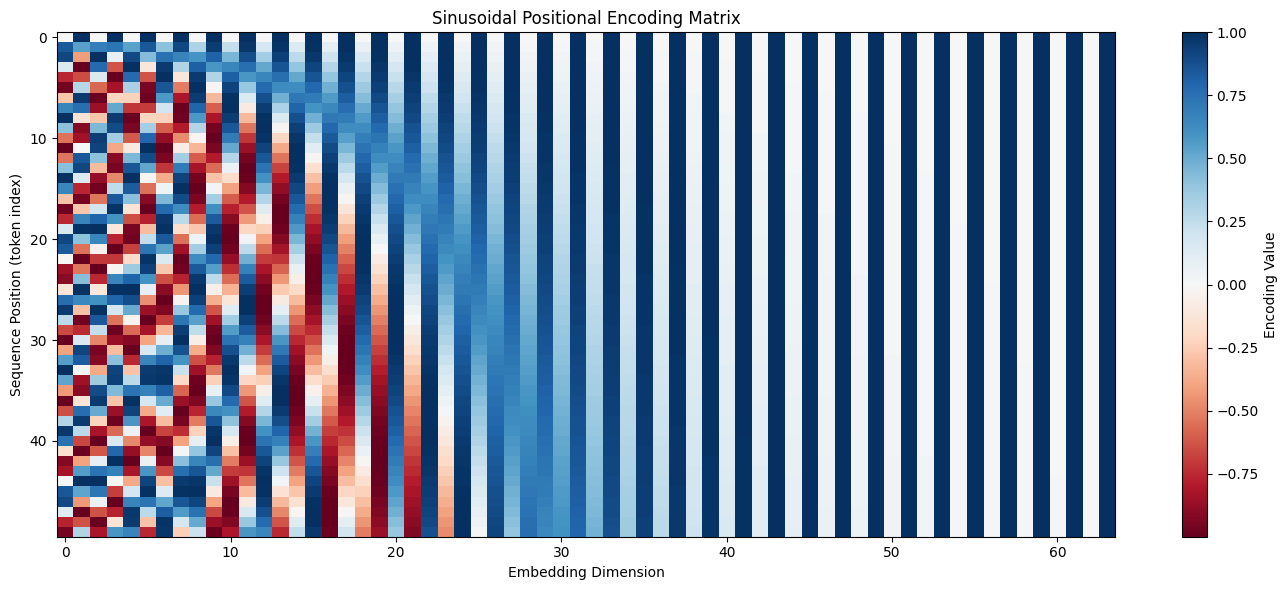

In [3]:
pe = positional_encoding(max_seq_len, d_model)

plt.figure(figsize=(14, 6))
plt.imshow(pe.numpy(), aspect='auto', cmap='RdBu', origin='upper')
plt.colorbar(label='Encoding Value')
plt.xlabel('Embedding Dimension')
plt.ylabel('Sequence Position (token index)')
plt.title('Sinusoidal Positional Encoding Matrix')
plt.tight_layout()
plt.show()

**EMBEDDING + PE MODULE**

In [4]:
class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len):
        super().__init__()
        self.embeddingg = nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(max_seq_len, d_model)

    def forward(self, x):
        token_embeddings = self.embeddingg(x)  
        seq_len = x.shape[1]
        return token_embeddings + self.pe[:seq_len, :]

**What this is:** An `nn.Module wraps` your logic into a reusable PyTorch layer.
>
***nn.Embedding*** is a learnable lookup table — a matrix of shape (vocab_size, d_model). Given a token index, it returns the corresponding row. This is the learned part.
>
The PE is **fixed** (not learned) — we add it on top. The model adapts its embeddings during training to work with the fixed position signal.
x.shape[1] is your sequence length — we slice the PE to match so it works for any input length up to max_seq_len.

**SANITY CHECK**

In [5]:
embed_layer = InputEmbedding(vocab_size, d_model, max_seq_len)

dummy_tokens = torch.randint(0, vocab_size, (1, 10))
output = embed_layer(dummy_tokens)

print(f"Input token shape:  {dummy_tokens.shape}")
print(f"Output embedding shape: {output.shape}")

Input token shape:  torch.Size([1, 10])
Output embedding shape: torch.Size([1, 10, 64])


## Sprint 1 Summary — Input Embeddings + Positional Encoding

- Transformers process all tokens in parallel, so they have no built-in sense of order.
- We fix this by adding a **positional encoding** matrix to the token embeddings before processing.
- Token embeddings are **learned** (nn.Embedding lookup table).
- Positional encodings are **fixed** sinusoidal signals — each position gets a unique fingerprint.
- The encoding formula uses sine for even dimensions and cosine for odd dimensions, at different frequencies.
- The final input is: `token_embedding + positional_encoding`
- Output shape flowing into the Transformer: `(batch_size, seq_len, d_model)`